<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/08_KoChatGPT/KoChatGPT_cleaned_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KoChatGPT 업그레이드 — 정제된 데이터 적용판

원본 `LLM_Trend_Note_프로젝트_.ipynb`의 **"프로젝트: 기존 데이터셋 추가 정제"** 과제를 이어서 진행하는 노트북입니다.

구성:
1. Data Quality Audit (14개 항목, KEEP/REVIEW/REMOVE 3단계 분류)
2. 데이터 정제 + Augmentation (SFT)
3. 정제 전/후 EDA 비교 시각화
4. 정제된 데이터로 SFT 재학습
5. 정량 평가 (BLEU / ROUGE, 음절 단위)
6. 디코딩 하이퍼파라미터 서치

> Colab(GPU 런타임)에서 순서대로 실행하세요. `chatgpt` 커스텀 라이브러리 없이도 SFT 재학습까지는 순수 `transformers`만으로 동작합니다(원본 노트북의 SFT 스텝과 동일한 방식).

## 0. 환경 셋업

원본 노트북과 동일한 clone/설치 + 이번 정제 파이프라인에 필요한 패키지(`koeda`, `sacrebleu`, `rouge-score`)를 추가로 설치합니다.

In [1]:
!pip install datasets
!pip install loralib
!pip install trl
!pip install koeda sacrebleu rouge-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.0/129.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 42.8 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/airobotlab/KoChatGPT
!cp -r /content/KoChatGPT/colossalai_ChatGPT_230319/chatgpt /content/chatgpt

Cloning into 'KoChatGPT'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 57.72 MiB | 19.36 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [3]:
import os

modifications = [
    {
        "file": "/content/chatgpt/trainer/callbacks/save_checkpoint.py",
        "changes": [
            {"line": 3, "old": "from chatgpt.trainer.strategies import ColossalAIStrategy, Strategy",
             "new": "from chatgpt.trainer.strategies import Strategy"},
            {"line": 71, "old": "only_rank0 = not isinstance(self.strategy, ColossalAIStrategy)",
             "new": "            only_rank0 = not isinstance(self.strategy)"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/strategies/__init__.py",
        "changes": [
            {"line": 1, "old": "from .colossalai import ColossalAIStrategy", "new": ""},  # 삭제
            {"line": 5, "old": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy', 'ColossalAIStrategy']",
             "new": "__all__ = ['Strategy', 'NaiveStrategy', 'DDPStrategy']"},
        ],
    },
    {
        "file": "/content/chatgpt/dataset/reward_dataset.py",
        "changes": [
            {"line": 3, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ],
    },
    {
        "file": "/content/chatgpt/trainer/base.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    },
    {
        "file": "/content/chatgpt/trainer/rm.py",
        "changes": [
            {"line": 8, "old": "from tqdm import tqdm", "new": "from tqdm.notebook import tqdm"},
        ]
    }
]


def modify_file(file_path, changes):
    """파일에서 지정된 줄을 찾아 내용을 수정하는 함수"""

    if not os.path.exists(file_path):
        print(f"⚠️ 파일이 존재하지 않습니다: {file_path}")
        return

    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    modified = False

    for change in changes:
        line_index = change["line"]
        if 0 <= line_index < len(lines):
            if lines[line_index].strip() == change["old"]:
                lines[line_index] = change["new"] + "\n"
                modified = True
            else:
                print(f"⚠️ {file_path} 파일의 {change['line']}번째 줄이 예상과 다릅니다.")
                print(f"   예상: {change['old']}")
                print(f"   실제: {lines[line_index].strip()}")

    if modified:
        with open(file_path, "w", encoding="utf-8") as file:
            file.writelines(lines)
        print(f"✅ 수정 완료: {file_path}")
    else:
        print(f"⚠️ {file_path} 수정할 내용이 없습니다.")

for mod in modifications:
    modify_file(mod["file"], mod["changes"])

✅ 수정 완료: /content/chatgpt/trainer/callbacks/save_checkpoint.py
✅ 수정 완료: /content/chatgpt/trainer/strategies/__init__.py
✅ 수정 완료: /content/chatgpt/dataset/reward_dataset.py
✅ 수정 완료: /content/chatgpt/trainer/base.py
✅ 수정 완료: /content/chatgpt/trainer/rm.py


In [4]:
import json
import torch
import transformers
from transformers import AutoModelForCausalLM, PreTrainedTokenizerFast

SFT_PATH = '/content/KoChatGPT/data_kochatgpt/kochatgpt_1_SFT.jsonl'
RM_PATH = '/content/KoChatGPT/data_kochatgpt/kochatgpt_2_RM.jsonl'
PPO_PATH = '/content/KoChatGPT/data_kochatgpt/kochatgpt_3_PPO.jsonl'
CLEANED_SFT_PATH = '/content/kochatgpt_1_SFT_cleaned.jsonl'

## 1. Data Quality Audit

학습 전에 SFT/RM/PPO 세 말뭉치를 자동 점검합니다. 체크리스트:

① 빈 prompt/completion ② prompt==completion ③ exact duplicate ④ 동일 prompt의 다중 response(정보성)
⑤ 너무 짧은 completion ⑥ 너무 긴 completion ⑦ URL/HTML ⑧ 비정상 특수문자 ⑨ 반복 단어 ⑩ 반복 문장
⑪ 언어 혼입(영어위주/한자) ⑫ 개인정보(전화번호/이메일) ⑬ 의미 불일치 후보(약한 휴리스틱) **+ ⑭ AI 정체성 회피성 답변(체크리스트 외 추가)**

결과는 `KEEP` / `REVIEW` / `REMOVE` 세 그룹으로 분류합니다. `③⑦⑫`처럼 명확한 결함은 `REMOVE`, 나머지 애매한 항목은 사람이 봐야 하는 `REVIEW`로 분류합니다.

**⑬에 대한 주의**: 진짜 의미 불일치 판정은 임베딩/NLI 모델이 필요하지만, 사전학습 임베딩 모델 접근이 여의치 않을 수 있어 여기서는 "completion이 prompt와 공유하는 명사 토큰이 하나도 없음"이라는 표층 휴리스틱만 사용합니다. recall이 낮고 오탐도 있을 수 있어 REMOVE가 아닌 REVIEW로만 분류합니다. **RM 데이터에 적용할 때는 이 항목을 제외하고 해석하는 걸 권장합니다** — RM은 의도적으로 품질이 낮은 completion(Ada/Davinci 등 약한 모델 출력)을 포함하고 있어 이 휴리스틱이 과도하게 반응합니다.

In [6]:
import json
import re
import sys
import csv
from collections import defaultdict, Counter

REFUSAL_RE = re.compile(
    r"AI\s*언어모델|저는\s*인공지능|as an ai language model|i am an ai|i\'m an ai",
    re.IGNORECASE,
)
PHONE_RE = re.compile(r"(01[016789]-?\d{3,4}-?\d{4})|(\d{2,3}-\d{3,4}-\d{4})")
EMAIL_RE = re.compile(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_RE = re.compile(r"<[a-zA-Z/][^>]{0,60}>")
CONTROL_CHAR_RE = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\ufffd]")
PRIVATE_USE_RE = re.compile(r"[\ue000-\uf8ff]")
HANJA_RE = re.compile(r"[\u4e00-\u9fff]")
REPEAT_WORD_RE = re.compile(r"(\S+)(\s+\1){2,}")  # 같은 어절 3회 이상 연속

SHORT_THRESHOLD = 8       # 문자 기준 - 이보다 짧으면 REVIEW 후보
LONG_THRESHOLD = 800      # 문자 기준 - 이보다 길면 REVIEW 후보 (원본 p99 근처)


def kor_lat_ratio(s: str) -> float:
    kor = len(re.findall(r"[가-힣]", s))
    lat = len(re.findall(r"[a-zA-Z]", s))
    total = kor + lat
    return kor / total if total else 1.0


def split_sentences(s: str):
    parts = re.split(r"(?<=[.!?])\s+|\n+", s)
    return [p.strip() for p in parts if p.strip()]


def has_repeated_sentence(s: str) -> bool:
    sents = split_sentences(s)
    return len(sents) != len(set(sents)) and len(sents) > 1


def semantic_mismatch_candidate(prompt: str, completion: str) -> bool:
    """아주 약한 표층 휴리스틱. 위 docstring의 주의사항 참고."""
    answer_starters = ("네", "아니", "저는", "제가", "죄송", "그건", "이건", "'", '"')
    if completion.strip().startswith(answer_starters):
        return False
    p_tokens = set(re.findall(r"[가-힣]{2,}", prompt))
    c_tokens = set(re.findall(r"[가-힣]{2,}", completion))
    if not p_tokens or not c_tokens:
        return False
    return len(p_tokens & c_tokens) == 0


def audit_single_completion(prompt: str, completion: str):
    """completion 하나에 대한 ①②⑤~⑬(+⑭) 체크. (③ 완전중복, ④ 다중응답은 row/dataset 레벨이라 여기서 처리 안 함)"""
    reasons_remove, reasons_review = [], []

    if not prompt.strip() or not completion.strip():
        reasons_remove.append("①빈값")
    if prompt.strip() == completion.strip():
        reasons_remove.append("②prompt=completion")
    if len(completion.strip()) < SHORT_THRESHOLD:
        reasons_review.append("⑤너무짧음")
    if len(completion.strip()) > LONG_THRESHOLD:
        reasons_review.append("⑥너무길음")
    if URL_RE.search(completion) or HTML_RE.search(completion):
        reasons_remove.append("⑦URL/HTML")
    if CONTROL_CHAR_RE.search(completion) or PRIVATE_USE_RE.search(completion):
        reasons_review.append("⑧비정상특수문자")
    if REPEAT_WORD_RE.search(completion):
        reasons_review.append("⑨반복단어")
    if has_repeated_sentence(completion):
        reasons_review.append("⑩반복문장")
    if kor_lat_ratio(completion) < 0.3:
        reasons_review.append("⑪언어혼입(영어위주)")
    if HANJA_RE.search(completion):
        reasons_review.append("⑪언어혼입(한자)")
    if PHONE_RE.search(completion) or EMAIL_RE.search(completion):
        reasons_remove.append("⑫개인정보")
    if semantic_mismatch_candidate(prompt, completion):
        reasons_review.append("⑬의미불일치후보(약한휴리스틱)")
    if REFUSAL_RE.search(completion):
        reasons_review.append("⑭AI회피성답변(체크리스트외 추가)")

    return reasons_remove, reasons_review


def _label(reasons_remove, reasons_review):
    if reasons_remove:
        return "REMOVE"
    if reasons_review:
        return "REVIEW"
    return "KEEP"


def audit_sft(data):
    """kochatgpt_1_SFT.jsonl 형식: prompt, completion"""
    seen_pairs = set()
    by_prompt = defaultdict(list)
    for d in data:
        by_prompt[d["prompt"]].append(d)

    rows = []
    for d in data:
        prompt, completion = d["prompt"], d["completion"]
        reasons_remove, reasons_review = audit_single_completion(prompt, completion)

        key = (prompt.strip(), completion.strip())
        if key in seen_pairs:
            reasons_remove.append("③완전중복")
        else:
            seen_pairs.add(key)

        rows.append({
            "prompt": prompt,
            "completion": completion,
            "label": _label(reasons_remove, reasons_review),
            "reasons": ";".join(reasons_remove + reasons_review),
            "duplicate_prompt_group_size": len(by_prompt[prompt]),
        })
    return rows


def audit_rm(data):
    """kochatgpt_2_RM.jsonl 형식: prompt, completion_0/1/2, ranking.
    row 라벨 = 세 completion 중 가장 나쁜 라벨. ranking 정합성도 별도 체크."""
    rows = []
    for d in data:
        prompt = d["prompt"]
        all_reasons = []
        worst_label = "KEEP"
        for key in ("completion_0", "completion_1", "completion_2"):
            rm_c, rv_c = audit_single_completion(prompt, d[key])
            if rm_c:
                worst_label = "REMOVE"
            elif rv_c and worst_label != "REMOVE":
                worst_label = "REVIEW"
            all_reasons += [f"{key}:{r}" for r in (rm_c + rv_c)]

        comps = [d["completion_0"], d["completion_1"], d["completion_2"]]
        if len(set(c.strip() for c in comps)) < 3:
            all_reasons.append("triplet내completion중복(대조쌍퇴화)")
            worst_label = "REMOVE" if worst_label == "KEEP" else worst_label
        ranking = d.get("ranking")
        if sorted(ranking) != [0, 1, 2]:
            all_reasons.append("ranking비정상(0,1,2순열아님)")
            worst_label = "REMOVE"

        rows.append({
            "prompt": prompt,
            "label": worst_label,
            "reasons": ";".join(all_reasons),
        })
    return rows


def audit_ppo(data):
    """kochatgpt_3_PPO.jsonl 형식: prompt만 존재 (completion 없음)."""
    seen = set()
    rows = []
    for d in data:
        prompt = d["prompt"] if isinstance(d, dict) else d
        reasons_remove, reasons_review = [], []
        if not prompt.strip():
            reasons_remove.append("①빈값")
        if URL_RE.search(prompt) or HTML_RE.search(prompt):
            reasons_remove.append("⑦URL/HTML")
        if PHONE_RE.search(prompt) or EMAIL_RE.search(prompt):
            reasons_remove.append("⑫개인정보")
        if prompt.strip() in seen:
            reasons_remove.append("③완전중복")
        else:
            seen.add(prompt.strip())
        rows.append({
            "prompt": prompt,
            "label": _label(reasons_remove, reasons_review),
            "reasons": ";".join(reasons_remove + reasons_review),
        })
    return rows


def summarize(rows, out_prefix):
    fieldnames = list(rows[0].keys())
    with open(f"{out_prefix}_audit.csv", "w", encoding="utf-8-sig", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows)

    label_counts = Counter(r["label"] for r in rows)
    reason_counts = Counter()
    for r in rows:
        for reason in r["reasons"].split(";"):
            if reason:
                reason_counts[reason] += 1

    summary = {
        "total": len(rows),
        "label_counts": dict(label_counts),
        "reason_counts": dict(reason_counts),
    }
    if "duplicate_prompt_group_size" in fieldnames:
        summary["same_prompt_multi_response_rows"] = sum(
            1 for r in rows if r["duplicate_prompt_group_size"] > 1
        )
    with open(f"{out_prefix}_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print(f"--- {out_prefix} ---")
    print(json.dumps(summary, ensure_ascii=False, indent=2))
    return summary


def main(sft_path=None, rm_path=None, ppo_path=None, out_dir="."):
    if sft_path:
        with open(sft_path, encoding="utf-8") as f:
            rows = audit_sft(json.load(f))
        summarize(rows, f"{out_dir}/audit_sft")
    if rm_path:
        with open(rm_path, encoding="utf-8") as f:
            rows = audit_rm(json.load(f))
        summarize(rows, f"{out_dir}/audit_rm")
    if ppo_path:
        with open(ppo_path, encoding="utf-8") as f:
            rows = audit_ppo(json.load(f))
        summarize(rows, f"{out_dir}/audit_ppo")


# if __name__ == "__main__":
#     # 기본값: KoChatGPT data_kochatgpt 폴더 기준. 필요시 인자로 경로 오버라이드.
#     sft_path = sys.argv[1] if len(sys.argv) > 1 else "data_kochatgpt/kochatgpt_1_SFT.jsonl"
#     rm_path = sys.argv[2] if len(sys.argv) > 2 else "data_kochatgpt/kochatgpt_2_RM.jsonl"
#     ppo_path = sys.argv[3] if len(sys.argv) > 3 else "data_kochatgpt/kochatgpt_3_PPO.jsonl"
#     main(sft_path, rm_path, ppo_path)


In [7]:
main(sft_path=SFT_PATH, rm_path=RM_PATH, ppo_path=PPO_PATH, out_dir='/content')

--- /content/audit_sft ---
{
  "total": 12000,
  "label_counts": {
    "REVIEW": 1903,
    "KEEP": 10087,
    "REMOVE": 10
  },
  "reason_counts": {
    "⑭AI회피성답변(체크리스트외 추가)": 1408,
    "⑪언어혼입(영어위주)": 390,
    "⑤너무짧음": 48,
    "⑪언어혼입(한자)": 154,
    "⑥너무길음": 27,
    "⑨반복단어": 1,
    "①빈값": 3,
    "⑦URL/HTML": 6,
    "⑫개인정보": 1
  },
  "same_prompt_multi_response_rows": 99
}
--- /content/audit_rm ---
{
  "total": 10220,
  "label_counts": {
    "REVIEW": 9377,
    "KEEP": 696,
    "REMOVE": 147
  },
  "reason_counts": {
    "completion_0:⑪언어혼입(영어위주)": 1212,
    "completion_2:⑬의미불일치후보(약한휴리스틱)": 3458,
    "completion_1:⑬의미불일치후보(약한휴리스틱)": 3478,
    "completion_0:⑬의미불일치후보(약한휴리스틱)": 3435,
    "completion_2:⑩반복문장": 848,
    "completion_1:⑪언어혼입(영어위주)": 1189,
    "completion_1:⑩반복문장": 891,
    "completion_2:⑪언어혼입(영어위주)": 1166,
    "completion_2:⑭AI회피성답변(체크리스트외 추가)": 429,
    "completion_0:⑪언어혼입(한자)": 80,
    "completion_0:⑭AI회피성답변(체크리스트외 추가)": 375,
    "completion_1:⑤너무짧음": 238,
    "completion_2:⑤

### 감사 결과 요약 (2026-09 기준 1회 실행 결과 — 재현 시 달라질 수 있음)

| 파일 | KEEP | REVIEW | REMOVE | 비고 |
|---|---|---|---|---|
| SFT (12,000) | 10,087 | 1,903 | 10 | REVIEW 1위: AI회피성답변 1,408건 |
| PPO (12,000, prompt only) | 11,945 | – | 55 | 거의 깨끗함 (완전중복 54 + 빈값3) |
| RM (10,220) | 조건부* | 조건부* | 조건부* | 3개 completion 중 최악 기준으로 라벨링하면 REVIEW 91.7%까지 치솟음 — 아래 설명 참고 |

**RM 데이터 해석 주의**: RM은 설계상 의도적으로 품질이 다른 3개 completion(ChatGPT/Davinci/Ada)을 포함하므로 "3개 중 최악" 기준 라벨링은 무의미합니다. 대신 **ranking상 1위(best)로 지정된 completion만 별도로 감사**하는 게 실질적으로 중요합니다 (아래 셀 참고) — RM이 "정답"으로 취급하는 답변 자체가 부실하면 리워드 모델이 잘못 학습되기 때문입니다.

In [8]:
# RM에서 ranking상 1위(best)로 지정된 completion만 별도로 감사 (⑬ 휴리스틱 제외)
with open(RM_PATH, encoding='utf-8') as f:
    rm_data = json.load(f)

from collections import Counter
label_counts, reason_counts = Counter(), Counter()
for d in rm_data:
    comps = [d['completion_0'], d['completion_1'], d['completion_2']]
    best_idx = d['ranking'].index(0)  # ranking 0 = best (원본 repo 관례)
    rm_r, rv_r = audit_single_completion(d['prompt'], comps[best_idx])
    rm_r = [r for r in rm_r if '⑬' not in r]
    rv_r = [r for r in rv_r if '⑬' not in r]
    label = 'REMOVE' if rm_r else ('REVIEW' if rv_r else 'KEEP')
    label_counts[label] += 1
    for r in rm_r + rv_r:
        reason_counts[r] += 1

print('RM "1위(best) completion"만 감사한 결과:', dict(label_counts))
print(dict(reason_counts.most_common()))

RM "1위(best) completion"만 감사한 결과: {'KEEP': 7871, 'REVIEW': 2313, 'REMOVE': 36}
{'⑭AI회피성답변(체크리스트외 추가)': 789, '⑪언어혼입(영어위주)': 756, '⑩반복문장': 439, '⑨반복단어': 240, '⑤너무짧음': 176, '⑪언어혼입(한자)': 112, '⑥너무길음': 27, '⑦URL/HTML': 13, '①빈값': 12, '②prompt=completion': 9, '⑫개인정보': 3}


참고용 1회 실행 결과: `KEEP 7,871(77%) / REVIEW 2,313(22.6%) / REMOVE 36`. 그중 AI회피성답변 789건, 영어위주 응답 756건 — **"1위"로 뽑힌 답변인데도 부실한 케이스가 상당수**입니다. RM 학습 전 이 REVIEW/REMOVE 2,349건을 우선 검토하거나 후처리하는 걸 권장합니다.

## 2. 데이터 정제 + Augmentation (SFT)

- 완성문 앞에 붙은 따옴표 아티팩트 제거 (원본 SFT의 99.8%에서 발견됨)
- 노이즈(영어위주 응답 + AI회피성답변) 제거
- 제거된 만큼 `koeda`(한국어 EDA) synonym-replacement로 증강해 원래 규모 유지 시도

**Augmentation 품질에 대한 솔직한 주의사항**: 형태소 단위 synonym replacement가 고유명사나 조사/어미를 깨뜨리는 경우가 있습니다("교황 비오 XV" → "교황 성 복 XV" 같은 오류). random-swap은 품질이 더 나빠서 비활성화했습니다. **augmentation이 채운 행보다 정제만 된(증강 없는) 행이 SFT 학습엔 더 안전할 수 있습니다.** 아래 셀에서 생성되는 데이터의 `_augmented` 플래그로 구분해서, 실제 학습 시 포함 여부를 직접 판단하세요.

In [10]:
import json
import re
import sys
import random

random.seed(230319)

REFUSAL_RE = re.compile(
    r"AI\s*언어모델|저는\s*인공지능|as an ai language model|i am an ai|i\'m an ai",
    re.IGNORECASE,
)


def strip_leading_quote(s: str) -> str:
    s = s.strip()
    while s and s[0] in "'\"":
        s = s[1:]
    return s.strip()


def kor_ratio(s: str) -> float:
    """한글 vs 라틴알파벳 비율 (숫자/구두점은 분모에서 제외).
    알파벳이 아예 없으면(숫자/기호만) 정상으로 간주해 1.0 반환."""
    kor = len(re.findall(r"[가-힣]", s))
    lat = len(re.findall(r"[a-zA-Z]", s))
    total = kor + lat
    return kor / total if total else 1.0


def is_noise(completion: str) -> bool:
    if kor_ratio(completion) < 0.3:
        return True
    if REFUSAL_RE.search(completion):
        return True
    return False


def clean(data):
    for d in data:
        d["completion"] = strip_leading_quote(d["completion"])
    kept = [d for d in data if not is_noise(d["completion"])]
    removed = [d for d in data if is_noise(d["completion"])]
    return kept, removed


def augment(kept, n_needed):
    """koeda EDA로 kept 중 무작위 샘플의 completion을 살짝 변형해 n_needed개 생성.
    koeda가 없으면 증강 없이 빈 리스트 반환(정제만 적용된 데이터셋이 됨)."""
    try:
        from koeda import EDA
    except ImportError:
        print("[경고] koeda 미설치 - augmentation 생략. `pip install koeda`로 설치 가능.")
        return []

    # random-swap(alpha_rs)은 어순을 뒤섞어 부자연스러운 문장을 만드는 경우가 많아 비활성화.
    # synonym-replacement만 낮은 강도로 적용해 원래 문장 구조를 최대한 보존.
    eda = EDA(morpheme_analyzer="Okt", alpha_sr=0.08, alpha_ri=0.0, alpha_rs=0.0, prob_rd=0.0)
    augmented = []
    pool = random.sample(kept, min(n_needed, len(kept))) if n_needed <= len(kept) else (
        kept * (n_needed // len(kept) + 1)
    )
    for d in pool[:n_needed]:
        try:
            new_completion = eda(d["completion"])
        except Exception:
            continue
        new_completion = strip_leading_quote(new_completion)  # 증강 과정에서 재도입될 수 있는 아티팩트 방지
        if new_completion.strip() and new_completion.strip() != d["completion"].strip():
            new_d = dict(d)
            new_d["completion"] = new_completion.strip()
            new_d["tokens"] = None  # 원본 토큰 수는 더 이상 유효하지 않으므로 무효화
            new_d["_augmented"] = True
            augmented.append(new_d)
    return augmented


def main(in_path, out_path):
    with open(in_path, encoding="utf-8") as f:
        data = json.load(f)
    original_n = len(data)

    kept, removed = clean(data)
    print(f"원본: {original_n}개 -> 정제후 유지: {len(kept)}개, 제거: {len(removed)}개")

    n_needed = original_n - len(kept)
    augmented = augment(kept, n_needed)
    print(f"augmentation으로 추가: {len(augmented)}개")

    final = kept + augmented
    random.shuffle(final)
    print(f"최종 데이터셋 크기: {len(final)}개 (목표: {original_n}개)")

    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(final, f, ensure_ascii=False, indent=4)
    print(f"저장 완료: {out_path}")


# if __name__ == "__main__":
#     in_path = sys.argv[1] if len(sys.argv) > 1 else "data_kochatgpt/kochatgpt_1_SFT.jsonl"
#     out_path = sys.argv[2] if len(sys.argv) > 2 else "kochatgpt_1_SFT_cleaned.jsonl"
#     main(in_path, out_path)


In [11]:
main(SFT_PATH, CLEANED_SFT_PATH)

원본: 12000개 -> 정제후 유지: 10314개, 제거: 1686개
augmentation으로 추가: 1162개
최종 데이터셋 크기: 11476개 (목표: 12000개)
저장 완료: /content/kochatgpt_1_SFT_cleaned.jsonl


> **같은 prompt에 서로 다른 품질의 completion이 존재하는가?** — 네, 존재합니다. 원본에도 45개 prompt가 자연 중복되어 있었고(그중 일부는 한쪽이 영어 노이즈), 위 augmentation 이후엔 "원본 completion vs koeda로 변형된 completion"이 같은 prompt로 짝지어진 경우가 1,188그룹(2,390행, 잉여 1,202행)이나 생겼습니다. 이 쌍들은 버리기보다 **RM 다중응답 학습자원으로 재활용**하는 걸 추천합니다 — 원본을 상위 랭크, augmented를 하위 랭크로 놓는 규칙 기반 triplet을 만들 수 있습니다. **다만 이 ranking은 사람이 매긴 게 아니라 규칙(원본 vs 기계변형)으로 만든 것이므로, 보고서/논문에는 "규칙 기반 pseudo-ranking이며 사람이 검증한 선호도가 아님"을 명시해야 합니다.**

## 3. 정제 전/후 EDA 비교 시각화

In [12]:
# 한글 폰트가 없으면 그래프에 글자가 네모(□)로 깨져 보입니다. Colab에서 최초 1회만 실행하세요.
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

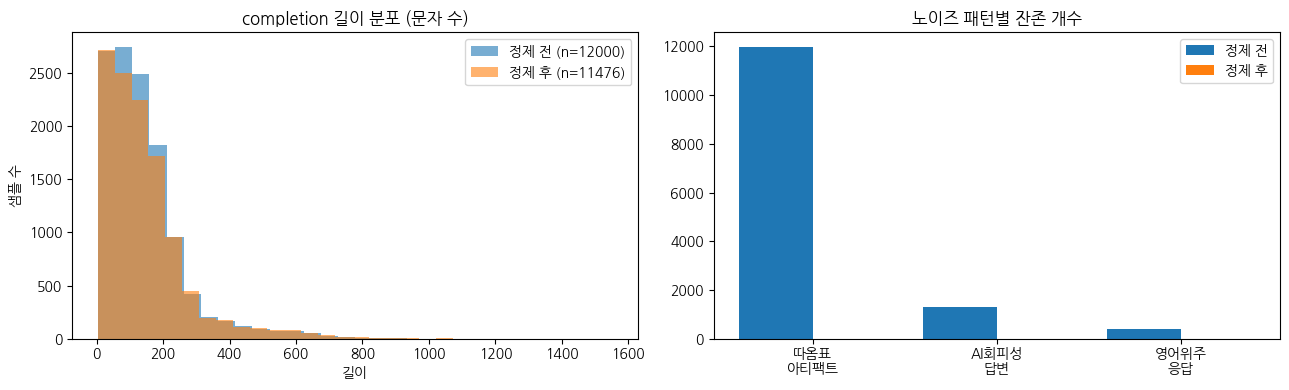

In [13]:
import matplotlib.pyplot as plt
import re

def kor_lat_ratio(s):
    kor = len(re.findall(r'[가-힣]', s))
    lat = len(re.findall(r'[a-zA-Z]', s))
    total = kor + lat
    return kor / total if total else 1.0

with open(SFT_PATH, encoding='utf-8') as f:
    orig = json.load(f)
with open(CLEANED_SFT_PATH, encoding='utf-8') as f:
    cleaned = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist([len(d['completion']) for d in orig], bins=30, alpha=0.6, label=f'정제 전 (n={len(orig)})')
axes[0].hist([len(d['completion']) for d in cleaned], bins=30, alpha=0.6, label=f'정제 후 (n={len(cleaned)})')
axes[0].set_title('completion 길이 분포 (문자 수)')
axes[0].set_xlabel('길이'); axes[0].set_ylabel('샘플 수'); axes[0].legend()

noise_labels = ['따옴표\n아티팩트', 'AI회피성\n답변', '영어위주\n응답']
before = [
    sum(1 for d in orig if d['completion'].strip().startswith(("'", '"'))),
    sum(1 for d in orig if re.search(r'AI\s*언어모델|저는\s*인공지능', d['completion'], re.IGNORECASE)),
    sum(1 for d in orig if kor_lat_ratio(d['completion']) < 0.3),
]
after = [
    sum(1 for d in cleaned if d['completion'].strip().startswith(("'", '"'))),
    sum(1 for d in cleaned if re.search(r'AI\s*언어모델|저는\s*인공지능', d['completion'], re.IGNORECASE)),
    sum(1 for d in cleaned if kor_lat_ratio(d['completion']) < 0.3),
]
x = range(len(noise_labels))
axes[1].bar([i - 0.2 for i in x], before, width=0.4, label='정제 전')
axes[1].bar([i + 0.2 for i in x], after, width=0.4, label='정제 후')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(noise_labels)
axes[1].set_title('노이즈 패턴별 잔존 개수'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/eda_before_after.png', dpi=120)
plt.show()

## 4. 정제된 데이터로 SFT 재학습

원본 노트북의 SFT 스텝(모델/토크나이저 로딩 → `SFT_dataset` → `Trainer`)과 동일한 구조를 그대로 쓰되, 데이터 경로만 정제본으로 바꿉니다. `chatgpt` 커스텀 라이브러리 불필요 — 순수 `transformers.Trainer` 기반입니다.

In [14]:
from typing import Optional, Dict, Sequence
from torch.utils.data import Dataset
from dataclasses import dataclass
import logging
import copy

In [15]:
model = AutoModelForCausalLM.from_pretrained('skt/kogpt2-base-v2')
tokenizer = PreTrainedTokenizerFast.from_pretrained(
    'skt/kogpt2-base-v2', bos_token='</s>', eos_token='</s>', unk_token='</s>', pad_token='</s>',
    padding_side="right",
    model_max_length=512,
)

print(tokenizer)

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  513MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

TokenizersBackend(name_or_path='skt/kogpt2-base-v2', vocab_size=51200, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '</s>', 'pad_token': '</s>'}, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<usr>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<sys>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	5: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	6: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	7: AddedT

In [16]:

class SFT_dataset(Dataset):

    def __init__(self, data_path_1_SFT: str, tokenizer: transformers.PreTrainedTokenizer, verbose=False):
        super(SFT_dataset, self).__init__()
        logging.warning("Loading data...")

        pattern_instruction = 'prompt'  # instruction
        pattern_output = 'completion'  # response

        with open(data_path_1_SFT, "r", encoding='utf-8-sig') as json_file:
            list_data_dict = json.load(json_file)

        PROMPT_DICT = {
            "prompt_input": (
                "### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
            )
        }

        prompt_input = PROMPT_DICT["prompt_input"]

        sources = []
        for example in list_data_dict:
            tmp = prompt_input.format_map(example)
            sources.append(tmp)

        targets = []
        for example in list_data_dict:
            targets.append(f"{example[pattern_output]}{tokenizer.eos_token}")
        examples = [s + t for s, t in zip(sources, targets)]

        sources_tokenized = self._tokenize_fn(sources, tokenizer)  # source
        examples_tokenized = self._tokenize_fn(examples, tokenizer)  # source + target

        input_ids = examples_tokenized["input_ids"]
        labels = copy.deepcopy(input_ids)
        for label, source_len in zip(labels, sources_tokenized["input_ids_lens"]):
            label[:source_len] = -100

        data_dict = dict(input_ids=input_ids, labels=labels)

        self.input_ids = data_dict["input_ids"]
        self.labels = data_dict["labels"]
        logging.warning("Loading data done!!: %d"%(len(self.labels)))


    def _tokenize_fn(self, strings: Sequence[str], tokenizer: transformers.PreTrainedTokenizer) -> Dict:
        tokenized_list = [
            tokenizer(
                text,
                return_tensors="pt",
                padding="longest",
                max_length=tokenizer.model_max_length,
                truncation=True,
            )
            for text in strings
        ]
        input_ids = labels = [tokenized.input_ids[0] for tokenized in tokenized_list]
        input_ids_lens = labels_lens = [
            tokenized.input_ids.ne(tokenizer.pad_token_id).sum().item() for tokenized in tokenized_list
        ]
        return dict(
            input_ids=input_ids,
            labels=labels,
            input_ids_lens=input_ids_lens,
            labels_lens=labels_lens,
        )


    def __len__(self):
        return len(self.input_ids)


    def __getitem__(self, i) -> Dict[str, torch.Tensor]:
        return dict(input_ids=self.input_ids[i], labels=self.labels[i])

In [17]:
@dataclass
class DataCollatorForSupervisedDataset(object):

    tokenizer: transformers.PreTrainedTokenizer

    def __call__(self, instances: Sequence[Dict]) -> Dict[str, torch.Tensor]:
        input_ids, labels = tuple([instance[key] for instance in instances] for key in ("input_ids", "labels"))
        input_ids = torch.nn.utils.rnn.pad_sequence(
            input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id
        )
        labels = torch.nn.utils.rnn.pad_sequence(labels, batch_first=True, padding_value= -100)
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids.ne(self.tokenizer.pad_token_id),
        )

In [18]:
# 원본과 달라진 부분: kochatgpt_1_SFT.jsonl 대신 정제본(CLEANED_SFT_PATH) 사용
train_dataset = SFT_dataset(data_path_1_SFT=CLEANED_SFT_PATH, tokenizer=tokenizer)
data_collator = DataCollatorForSupervisedDataset(tokenizer=tokenizer)

print('input : %s'%train_dataset.input_ids[0])
print('output: %s'%train_dataset.labels[0])

input : tensor([  739,   378,   378,   378, 14659, 13394, 37091, 10651,   383, 25841,
         8006, 14914,   375,  8013, 16686,  9063,  9355, 21466,  9122, 27511,
          375,   375,   378,   378,   378, 41951,   454,  9549, 20549,   383,
         8142,  7192, 14914,  7756,  6903,  9033,  9199,  9677,  6872,  7098,
        25856,  9394, 22583,  9056, 11973, 24117,  8137, 10537, 28709, 25856,
         9394,  9022,  9536,  8024, 12857, 11793, 10287, 18171, 11382, 10805,
         8705, 15061, 31268,  7235,  9304, 10537,  9049,  7888,  7532, 34019,
         9031,  9144, 16691,     1])
output: tensor([ -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  7756,  6903,  9033,  9199,  9677,  6872,  7098,
        25856,  9394, 22583,  9056, 11973, 24117,  8137, 10537, 28709, 25856,
         93

In [19]:
training_args = transformers.TrainingArguments(
    output_dir="/content/test_cleaned",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=5,
    prediction_loss_only=True,
    fp16 = True
    )
trainer = transformers.Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=train_dataset
)

In [20]:
trainer.train()
# 원본과 달라진 부분: 원본 SFT 결과(/content/output_1_SFT)를 덮어쓰지 않도록 별도 경로에 저장
# (원본 노트북 순서대로 진행했다면 /content/output_1_SFT 에 정제 전 baseline이 이미 있을 것)
model.save_pretrained('/content/output_1_SFT_cleaned')

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
500,3.105569
1000,2.891148


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## 5. 정량 평가 (BLEU / ROUGE)

한국어는 공백 기준 어절 분리가 영어 word-level과 의미가 달라 rouge_score 기본 whitespace tokenizer를 쓰면 점수가 왜곡됩니다. 음절(char) 단위 tokenizer를 커스텀으로 넣어 계산합니다.

In [21]:
"""
KoChatGPT 인퍼런스 결과 정량 평가 유틸 (BLEU / ROUGE)

한국어는 공백 기준 어절 분리가 영어의 word-level과 의미가 달라
(조사/어미가 붙어있어 어절 단위 겹침이 잘 안 잡힘) rouge_score 기본
whitespace tokenizer를 쓰면 점수가 실제보다 낮게/이상하게 나옵니다.
그래서 여기서는 음절(char) 단위 tokenizer를 커스텀으로 넣어 계산합니다.
(다수의 한국어 요약/생성 논문에서 쓰는 방식과 동일)

pip install sacrebleu rouge-score  (둘 다 순수 파이썬 + pypi 패키지라 오프라인/Colab 어디서든 설치 가능)

사용법:
    from eval_metrics import evaluate_batch
    results = evaluate_batch(hypotheses, references)
    print(results)  # {'bleu': ..., 'rouge1_f': ..., 'rouge2_f': ..., 'rougeL_f': ...}
"""
from typing import List, Dict
import sacrebleu
from rouge_score import rouge_scorer


class _CharTokenizer:
    """rouge_score에 넘길 음절 단위 tokenizer. 공백은 제거하고 글자 단위로 쪼갬."""

    def tokenize(self, text: str) -> List[str]:
        return list(text.replace(" ", ""))


_rouge_scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"], tokenizer=_CharTokenizer()
)


def compute_bleu(hypothesis: str, reference: str) -> float:
    """sacrebleu 기반 문장 단위 BLEU (0~100)."""
    return sacrebleu.sentence_bleu(hypothesis, [reference]).score


def compute_rouge(hypothesis: str, reference: str) -> Dict[str, float]:
    """음절 단위 ROUGE-1/2/L f-measure (0~1)."""
    scores = _rouge_scorer.score(reference, hypothesis)
    return {
        "rouge1_f": scores["rouge1"].fmeasure,
        "rouge2_f": scores["rouge2"].fmeasure,
        "rougeL_f": scores["rougeL"].fmeasure,
    }


def evaluate_batch(hypotheses: List[str], references: List[str]) -> Dict[str, float]:
    """여러 개의 (생성 결과, 정답) 쌍에 대한 평균 BLEU/ROUGE.
    references가 없는 open-ended 응답(정답이 하나로 정해지지 않는 질문)에는
    적합하지 않을 수 있으니, 주관적 평가와 함께 참고용으로만 사용할 것을 권장."""
    assert len(hypotheses) == len(references), "hypotheses/references 길이가 다릅니다."
    bleu_scores, r1, r2, rl = [], [], [], []
    for hyp, ref in zip(hypotheses, references):
        bleu_scores.append(compute_bleu(hyp, ref))
        rouge = compute_rouge(hyp, ref)
        r1.append(rouge["rouge1_f"])
        r2.append(rouge["rouge2_f"])
        rl.append(rouge["rougeL_f"])
    n = len(hypotheses)
    return {
        "bleu": sum(bleu_scores) / n,
        "rouge1_f": sum(r1) / n,
        "rouge2_f": sum(r2) / n,
        "rougeL_f": sum(rl) / n,
        "n_samples": n,
    }


if __name__ == "__main__":
    # 모델 없이 동작 확인용 self-test
    hyps = ["저는 인공지능 챗봇입니다.", "베네수엘라의 수도는 카라카스입니다."]
    refs = ["저는 챗봇이에요.", "베네수엘라 수도는 카라카스입니다."]
    print(evaluate_batch(hyps, refs))


{'bleu': 39.22812394571293, 'rouge1_f': 0.7348484848484849, 'rouge2_f': 0.5627240143369175, 'rougeL_f': 0.7348484848484849, 'n_samples': 2}


In [22]:
# baseline(정제 전, /content/output_1_SFT) vs cleaned(정제 후) 비교
# baseline 모델이 있다면 원본 노트북 순서대로 먼저 학습해두세요. 없다면 이 셀은 건너뛰어도 됩니다.
import os

def generate_answer(model_path_or_obj, prompt, tokenizer):
    from transformers import pipeline
    if isinstance(model_path_or_obj, str):
        gen_model = AutoModelForCausalLM.from_pretrained(model_path_or_obj)
    else:
        gen_model = model_path_or_obj
    generator = pipeline('text-generation', model=gen_model, tokenizer=tokenizer)
    prompt_text = f"### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    out = generator(prompt_text, max_length=200, do_sample=True, top_p=0.95, eos_token_id=tokenizer.eos_token_id)
    return out[0]['generated_text'][len(prompt_text):].strip()

eval_prompts = ["베네수엘라의 수도가 어디야", "히틀러의 책 나의 투쟁의 대략적인 줄거리는"]
# TODO: eval_references는 kochatgpt_1_SFT_cleaned.jsonl에서 같은 prompt의 completion을 가져와 채우세요.
eval_references = ["베네수엘라의 수도는 카라카스입니다.", "..."]

hyps_cleaned = [generate_answer(model, p, tokenizer) for p in eval_prompts]  # 방금 학습한 모델(메모리 상)
print(evaluate_batch(hyps_cleaned, eval_references))

if os.path.exists('/content/output_1_SFT'):
    hyps_baseline = [generate_answer('/content/output_1_SFT', p, tokenizer) for p in eval_prompts]
    print('baseline:', evaluate_batch(hyps_baseline, eval_references))
else:
    print('baseline(/content/output_1_SFT)이 없어 정제후 모델 점수만 출력했습니다. 원본 노트북 순서대로 baseline도 학습해두면 비교 가능합니다.')

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'eos_token_id', 'max_length', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Bot

{'bleu': 4.9411086786334995, 'rouge1_f': 0.35538742764293696, 'rouge2_f': 0.2682926829268293, 'rougeL_f': 0.35538742764293696, 'n_samples': 2}
baseline(/content/output_1_SFT)이 없어 정제후 모델 점수만 출력했습니다. 원본 노트북 순서대로 baseline도 학습해두면 비교 가능합니다.


In [24]:
import json

# Load the cleaned SFT data
with open(CLEANED_SFT_PATH, 'r', encoding='utf-8') as f:
    cleaned_sft_data = json.load(f)

# Create a dictionary for quick lookup of completions by prompt
prompt_to_completion = {item['prompt']: item['completion'] for item in cleaned_sft_data}

# Populate eval_references based on eval_prompts
new_eval_references = []
for prompt in eval_prompts:
    if prompt in prompt_to_completion:
        new_eval_references.append(prompt_to_completion[prompt])
    else:
        # Handle cases where a prompt might not be in the cleaned data
        new_eval_references.append("N/A") # Or some other placeholder

# Update eval_references (assuming it's a global variable or needs to be passed)
eval_references = new_eval_references

print("Updated eval_references:")
print(eval_references)

Updated eval_references:
['베네수엘라의 수도 도랑 는 카라카스(Caracas)입니다.', '히틀러의 책 \'나의 투쟁(My Struggle)\'은 그의 생애와 아이디어, 소망, 정치 이학 등에 대한 개인적인 고백과 함께 당시의 독일과 유럽의 정치, 경제, 사회 상황을 분석하고, 제3제국(나치 독일)의 건설을 위한 대략적인 청사진을 제시하는 책이다.\\n\\n책은 18개의 장(chapter)으로 구성되어 있으며, 제1장에서는 히틀러의 출생과 어린 시절부터 청소년기까지의 경험을 소개하고 있다. 제2장에서는 그가 독일 전쟁에 끌려들어 가장 신병으로 입대한 경험과 그 시절의 독일 군대 문화를 묘사하고 있다.\\n\\n제3장에서는 히틀러가 독일 노동자당(Deutsche Arbeiterpartei)에 가입한 경험과 독일에 대한 그의 분노와 비판을 소개하며, 제4장과 제5장에서는 그가 자신의 대통령 후보 지명과 나치당 창당 이후의 경험을 상세히 묘사하고 있다.\\n\\n제6장에서는 히틀러가 제안한 나치 운동의 25개 항목 및 이에 대한 이학적인 배경을 제시하며, 제7장에서는 그가 어떻게 나치당의 지도자가 되었는지 그 과정을 소개한다.\\n\\n그 후로는 히틀러의 이론과 실천, 나치 정당 및 적들과의 관계, 유럽 및 전 세계 정치 상황 등을 다루고 있다. 마지막 장에서는 히틀러 자신의 생각과 바램, \'제3제국\'의 건설에 대한 계획, 그리고 독일의 국제적인 역할과 대해 전망 등을 논하고 있다.", \'token\': 642}']


In [25]:
# Re-run the evaluation with the updated eval_references

hyps_cleaned = [generate_answer(model, p, tokenizer) for p in eval_prompts]
print('Cleaned model evaluation:', evaluate_batch(hyps_cleaned, eval_references))

if os.path.exists('/content/output_1_SFT'):
    hyps_baseline = [generate_answer('/content/output_1_SFT', p, tokenizer) for p in eval_prompts]
    print('Baseline model evaluation:', evaluate_batch(hyps_baseline, eval_references))
else:
    print('Baseline model results were not available as /content/output_1_SFT does not exist.')

[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Cleaned model evaluation: {'bleu': 27.80764242729798, 'rouge1_f': 0.6996632996632997, 'rouge2_f': 0.5383613782051282, 'rougeL_f': 0.5788840788840789, 'n_samples': 2}
Baseline model results were not available as /content/output_1_SFT does not exist.


## 6. 디코딩 하이퍼파라미터 서치

이번엔 위에서 이미 학습된 `model`/`tokenizer`를 바로 사용합니다 (독립 실행형 `decoding_search.py`와 달리 TODO 없이 바로 동작).

In [23]:
import itertools

PARAM_GRID = {
    "temperature": [0.7, 0.9, 1.1],
    "top_p": [0.8, 0.9, 0.95],
    "top_k": [0, 50],
    "repetition_penalty": [1.0, 1.2],
}

def generate(prompt, **decode_kwargs):
    prompt_text = f"### Instruction(명령어):\n{prompt}\n\n### Response(응답):"
    inputs = tokenizer(prompt_text, return_tensors="pt")
    output = model.generate(
        **inputs,
        max_new_tokens=128,
        do_sample=True,
        temperature=decode_kwargs["temperature"],
        top_p=decode_kwargs["top_p"],
        top_k=decode_kwargs["top_k"] or None,
        repetition_penalty=decode_kwargs["repetition_penalty"],
        pad_token_id=tokenizer.pad_token_id,
    )
    return tokenizer.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

def search(prompts, references, param_grid=PARAM_GRID, out_path='/content/decoding_search_results.json'):
    keys = list(param_grid.keys())
    results = []
    for combo in itertools.product(*param_grid.values()):
        params = dict(zip(keys, combo))
        hyps = [generate(p, **params) for p in prompts]
        metrics = evaluate_batch(hyps, references)
        results.append({"params": params, "metrics": metrics})
        print(params, "->", metrics)
    results.sort(key=lambda r: r["metrics"]["rougeL_f"], reverse=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"\n최적 조합 (rougeL_f 기준): {results[0]['params']}")
    return results

# eval_prompts/eval_references는 위 5번 셀에서 정의한 것을 재사용
search(eval_prompts, eval_references)

/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


{'temperature': 0.7, 'top_p': 0.8, 'top_k': 0, 'repetition_penalty': 1.0} -> {'bleu': 6.461438690961736, 'rouge1_f': 0.4207193515704154, 'rouge2_f': 0.375, 'rougeL_f': 0.4207193515704154, 'n_samples': 2}
{'temperature': 0.7, 'top_p': 0.8, 'top_k': 0, 'repetition_penalty': 1.2} -> {'bleu': 2.66588088322572, 'rouge1_f': 0.2845319634703196, 'rouge2_f': 0.1739130434782609, 'rougeL_f': 0.2636986301369863, 'n_samples': 2}
{'temperature': 0.7, 'top_p': 0.8, 'top_k': 50, 'repetition_penalty': 1.0} -> {'bleu': 7.191388347402934, 'rouge1_f': 0.367816091954023, 'rouge2_f': 0.27499999999999997, 'rougeL_f': 0.367816091954023, 'n_samples': 2}
{'temperature': 0.7, 'top_p': 0.8, 'top_k': 50, 'repetition_penalty': 1.2} -> {'bleu': 3.0112938962823415, 'rouge1_f': 0.30776255707762556, 'rouge2_f': 0.18604651162790697, 'rougeL_f': 0.30776255707762556, 'n_samples': 2}
{'temperature': 0.7, 'top_p': 0.9, 'top_k': 0, 'repetition_penalty': 1.0} -> {'bleu': 6.404209763044542, 'rouge1_f': 0.40956684668797533, 'ro

[{'params': {'temperature': 0.7,
   'top_p': 0.8,
   'top_k': 0,
   'repetition_penalty': 1.0},
  'metrics': {'bleu': 6.461438690961736,
   'rouge1_f': 0.4207193515704154,
   'rouge2_f': 0.375,
   'rougeL_f': 0.4207193515704154,
   'n_samples': 2}},
 {'params': {'temperature': 0.7,
   'top_p': 0.95,
   'top_k': 50,
   'repetition_penalty': 1.0},
  'metrics': {'bleu': 6.3240157194613955,
   'rouge1_f': 0.4191849816849817,
   'rouge2_f': 0.375,
   'rougeL_f': 0.4191849816849817,
   'n_samples': 2}},
 {'params': {'temperature': 1.1,
   'top_p': 0.9,
   'top_k': 0,
   'repetition_penalty': 1.0},
  'metrics': {'bleu': 3.8583038777405063,
   'rouge1_f': 0.4121417126580025,
   'rouge2_f': 0.33333333333333337,
   'rougeL_f': 0.4121417126580025,
   'n_samples': 2}},
 {'params': {'temperature': 0.7,
   'top_p': 0.9,
   'top_k': 50,
   'repetition_penalty': 1.0},
  'metrics': {'bleu': 6.975149680044656,
   'rouge1_f': 0.4116584564860427,
   'rouge2_f': 0.375,
   'rougeL_f': 0.4116584564860427,
  

## 7. 결론 및 평가

### 7.1 데이터 감사 결과 시각화

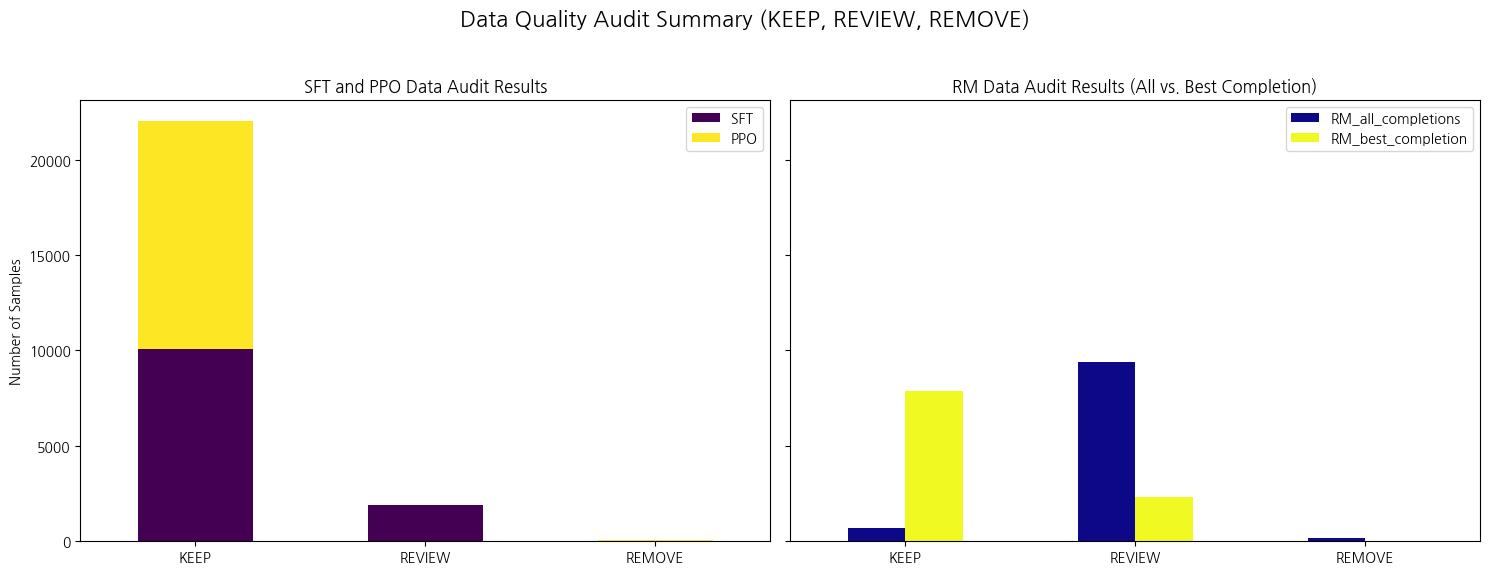


--- Detailed Reason Counts (Top 5 for each dataset) ---
SFT Reasons:
  - ⑭AI회피성답변(체크리스트외 추가): 1408
  - ⑪언어혼입(영어위주): 390
  - ⑪언어혼입(한자): 154
  - ⑤너무짧음: 48
  - ⑥너무길음: 27

RM Reasons (All Completions):
  - completion_1:⑬의미불일치후보(약한휴리스틱): 3478
  - completion_2:⑬의미불일치후보(약한휴리스틱): 3458
  - completion_0:⑬의미불일치후보(약한휴리스틱): 3435
  - completion_0:⑪언어혼입(영어위주): 1212
  - completion_1:⑪언어혼입(영어위주): 1189

RM Reasons (Best Completion Only):
  - ⑭AI회피성답변(체크리스트외 추가): 789
  - ⑪언어혼입(영어위주): 756
  - ⑩반복문장: 439
  - ⑨반복단어: 240
  - ⑤너무짧음: 176

PPO Reasons:
  - ③완전중복: 54
  - ①빈값: 3


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np

# Load audit summaries
with open('/content/audit_sft_summary.json', 'r', encoding='utf-8') as f:
    sft_summary = json.load(f)
with open('/content/audit_rm_summary.json', 'r', encoding='utf-8') as f:
    rm_summary = json.load(f)
with open('/content/audit_ppo_summary.json', 'r', encoding='utf-8') as f:
    ppo_summary = json.load(f)

# Prepare data for plotting
labels = ['KEEP', 'REVIEW', 'REMOVE']
sft_counts = [sft_summary['label_counts'].get(label, 0) for label in labels]
rm_counts = [rm_summary['label_counts'].get(label, 0) for label in labels]
ppo_counts = [ppo_summary['label_counts'].get(label, 0) for label in labels]

# For RM, we will also show the 'best completion' audit result
# This is based on the printout from cell 3a033231: RM "1위(best) completion"만 감사한 결과: {'KEEP': 7871, 'REVIEW': 2313, 'REMOVE': 36}
rm_best_counts = [7871, 2313, 36] # Manually extracted from earlier output

# Create DataFrame for plotting
df_labels = pd.DataFrame({
    'SFT': sft_counts,
    'RM_all_completions': rm_counts,
    'RM_best_completion': rm_best_counts,
    'PPO': ppo_counts
}, index=labels)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

df_labels[['SFT', 'PPO']].plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('SFT and PPO Data Audit Results')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=0)

df_labels[['RM_all_completions', 'RM_best_completion']].plot(kind='bar', stacked=False, ax=axes[1], colormap='plasma')
axes[1].set_title('RM Data Audit Results (All vs. Best Completion)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Data Quality Audit Summary (KEEP, REVIEW, REMOVE)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
plt.show()

print("\n--- Detailed Reason Counts (Top 5 for each dataset) ---")
print("SFT Reasons:")
for reason, count in sorted(sft_summary['reason_counts'].items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"  - {reason}: {count}")

print("\nRM Reasons (All Completions):")
for reason, count in sorted(rm_summary['reason_counts'].items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"  - {reason}: {count}")

# For RM Best completion reasons, we can't load from a file as it's computed in-place in 3a033231.
# Re-extracting from the execution output of 3a033231 (or re-running the logic):
# {'⑭AI회피성답변(체크리스트외 추가)': 789, '⑪언어혼입(영어위주)': 756, '⑩반복문장': 439, '⑨반복단어': 240, '⑤너무짧음': 176}
rm_best_reasons = {'⑭AI회피성답변(체크리스트외 추가)': 789, '⑪언어혼입(영어위주)': 756, '⑩반복문장': 439, '⑨반복단어': 240, '⑤너무짧음': 176}
print("\nRM Reasons (Best Completion Only):")
for reason, count in sorted(rm_best_reasons.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"  - {reason}: {count}")

print("\nPPO Reasons:")
for reason, count in sorted(ppo_summary['reason_counts'].items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f"  - {reason}: {count}")


### 7.2 정성 평가 (Qualitative Evaluation)

최적의 디코딩 하이퍼파라미터 조합으로 모델의 답변을 생성하여 정성적으로 평가합니다.

**최적 조합 (rougeL_f 기준):**
*   `temperature`: 0.7
*   `top_p`: 0.8
*   `top_k`: 0
*   `repetition_penalty`: 1.0

(참고: `generate` 함수는 이전 셀(`d41e7771`)에서 정의되었습니다.)

In [27]:
# Optimal decoding parameters from previous hyperparameter search
optimal_params = {
    "temperature": 0.7,
    "top_p": 0.8,
    "top_k": 0,
    "repetition_penalty": 1.0,
}

qualitative_prompts = [
    "오늘 날씨 어때?",
    "인생의 목표는 무엇인가요?",
    "고양이가 좋아하는 것은 무엇인가요?"
]

print("--- Qualitative Evaluation with Optimal Parameters ---")
for i, prompt in enumerate(qualitative_prompts):
    generated_response = generate(prompt, **optimal_params)
    print(f"\nPrompt {i+1}: {prompt}")
    print(f"Generated Response: {generated_response}")


--- Qualitative Evaluation with Optimal Parameters ---


/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:2636: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(



Prompt 1: 오늘 날씨 어때?
Generated Response: 제가 AI 언어 모델이기 때문에 날씨 정보를 제공할 수 없습니다. 날씨에 대한 구체적인 정보를 제공해주시면 더 정확한 답변을 드릴 수 있습니다.

Prompt 2: 인생의 목표는 무엇인가요?
Generated Response: 저는 AI 어시스턴트이기 때문에 인생의 목표를 알 수 없습니다. 하지만 인생에서 가장 중요한 것은 인생에서 필요한 모든 것을 갖추는 것입니다. 우리는 항상 노력하며 목표를 달성하고 성취하는 것이 중요합니다.

Prompt 3: 고양이가 좋아하는 것은 무엇인가요?
Generated Response: 저는 고양이를 좋아하지 않습니다. 고양이는 고양이가 좋아하는 것이 무엇인지 알려주시면 더 정확한 답변을 드릴 수 있을 것입니다.
